<a href="https://colab.research.google.com/github/Inokepa/generative-ai-for-beginners/blob/main/ClustersLC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import networkx as nx
import numpy as np
from scipy.linalg import eig

def calcular_laplaciano_complexo(G, alpha=0.85):
    """
    Implementa o Laplaciano Complexo Normalizado (Lc) segundo Jacinto Pessoa.
    G: Digrafo do NetworkX.
    alpha: Fator de amortecimento para garantir ergodicidade (irredutibilidade).
    """
    # 1. Obter a matriz de adjacência e converter para matriz de transição P
    # O NetworkX facilita isso com a função google_matrix (que já aplica o fator de teletransporte)
    # Isso garante a irredutibilidade e aperiodicidade necessárias.
    nodes = list(G.nodes())
    n = len(nodes)
    P_matrix = nx.google_matrix(G, alpha=alpha)
    P = np.array(P_matrix) # Matriz de transição estocástica [cite: 97, 146]

    # 2. Calcular a Distribuição Estacionária (pi) [cite: 99, 212]
    # pi é o autovetor à esquerda associado ao autovalor 1
    eigenvalues, left_eigenvectors = eig(P, left=True, right=False)
    # Encontrar o índice do autovalor 1
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    pi = np.real(left_eigenvectors[:, idx])
    pi = pi / np.sum(pi) # Normalização para que a soma seja 1 [cite: 212, 651]

    # 3. Construção do Laplaciano Complexo Lc [cite: 540, 663]
    # (Lc)_ij = 1 - Pii se i=j
    # (Lc)_ij = -Pij * sqrt(pi_i / pi_j) se i != j
    Lc = np.zeros((n, n), dtype=complex)

    for i in range(n):
        for j in range(n):
            if i == j:
                Lc[i, j] = 1.0 - P[i, j] # Parte real (difusão local) [cite: 664]
            else:
                # Ponderação pela raiz das massas estacionárias [cite: 663, 669]
                Lc[i, j] = -P[i, j] * np.sqrt(pi[i] / pi[j])

    return Lc, nodes

# Exemplo de Uso
# Criando um digrafo cíclico (com circulação líquida) [cite: 89, 404]
G = nx.DiGraph()
G.add_edges_from([(0, 1), (1, 2), (2, 0), (0, 2)])

Lc, nodes = calcular_laplaciano_complexo(G)

# 4. Decomposição Espectral [cite: 108, 531]
beta, v = eig(Lc)

# Ordenar pelos menores autovalores reais (difusão)
idx_sort = np.argsort(np.real(beta))
beta_sorted = beta[idx_sort]
v_sorted = v[:, idx_sort]

print(f"Menores Autovalores (beta): {beta_sorted[:3]}")
# A parte imaginária codifica a circulação [cite: 536, 721, 735]

Menores Autovalores (beta): [-3.41275288e-16+2.29049814e-17j  1.42500000e+00+4.25000000e-01j
  1.42500000e+00-4.25000000e-01j]


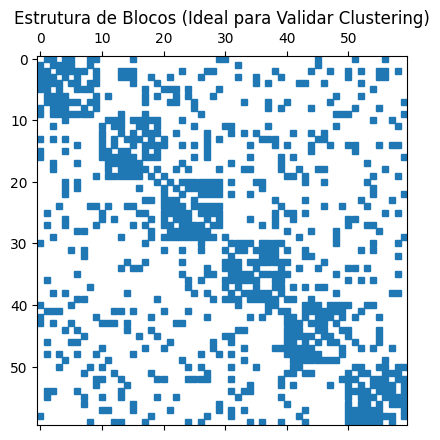

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def gerar_grafo_com_clusters(n_blocos, tamanho_bloco, p_interno, p_externo):
    """
    Gera um grafo com comunidades definidas para teste de clustering.
    n_blocos: Número de clusters.
    tamanho_bloco: Nós por cluster.
    p_interno: Prob. de conexão DENTRO do cluster (deve ser alta).
    p_externo: Prob. de conexão ENTRE clusters (deve ser baixa).
    """
    sizes = [tamanho_bloco] * n_blocos

    # Probabilidades de conexão (matriz de preferência)
    # A diagonal tem p_interno (conexão forte interna)
    # Fora da diagonal tem p_externo (ruído/conexão fraca)
    probs = np.full((n_blocos, n_blocos), p_externo)
    np.fill_diagonal(probs, p_interno)

    # Gera o grafo estocástico
    G = nx.stochastic_block_model(sizes, probs, directed=True)

    return G

# --- Exemplo de Uso para o seu Teste ---
# 3 Clusters de 10 nós cada.
# 80% de chance de conectar internamente, 5% de chance de conectar com outros.
G_teste = gerar_grafo_com_clusters(6, 10, 0.8, 0.15)

# O "ground truth" (a resposta certa) está guardado nos atributos dos nós
comunidades_reais = [G_teste.nodes[i]['block'] for i in G_teste.nodes()]

# Visualizar a Matriz de Adjacência (revelará os blocos)
plt.spy(nx.to_numpy_array(G_teste), markersize=5)
plt.title("Estrutura de Blocos (Ideal para Validar Clustering)")
plt.show()

In [ ]:

Lc, nodes = calcular_laplaciano_complexo(G_teste)

# 4. Decomposição Espectral [cite: 108, 531]
beta, v = eig(Lc)

# Ordenar pelos menores autovalores reais (difusão)
idx_sort = np.argsort(np.real(beta))
beta_sorted = beta[idx_sort]
v_sorted = v[:, idx_sort]

print(f"Menores Autovalores (beta): {beta_sorted[:3]}")

Menores Autovalores (beta): [1.34840551e-16+1.92727966e-18j 6.66598920e-01+8.41972598e-16j
 6.70333105e-01-1.35520421e-02j]


--- Gerando Grafo SBM Dirigido com 200 nós e 5 clusters ---

Testando de 2 a 10 clusters com ruído de 0.0%...
K=2 | ARI: 0.350
K=3 | ARI: 0.478
K=4 | ARI: 0.779
K=5 | ARI: 1.000
K=6 | ARI: 0.912
K=7 | ARI: 0.789
K=8 | ARI: 0.720
K=9 | ARI: 0.640
K=10 | ARI: 0.533


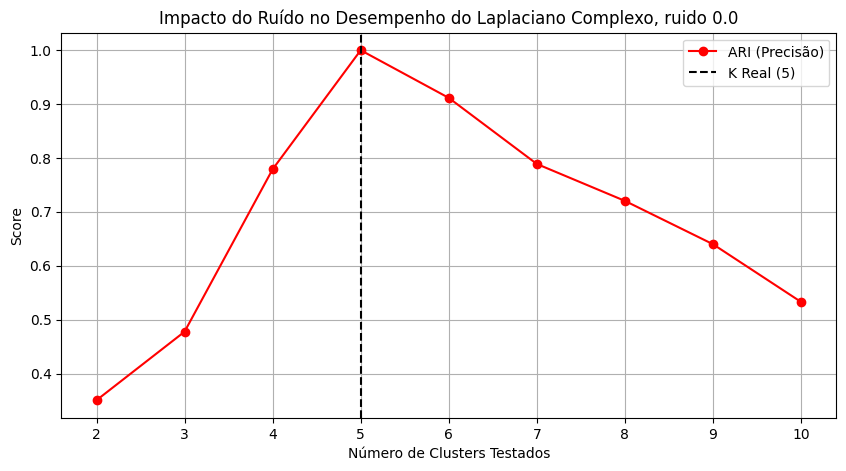

--- Gerando Grafo SBM Dirigido com 240 nós e 6 clusters ---

Testando de 2 a 10 clusters com ruído de 15.0%...
K=2 | ARI: 0.226
K=3 | ARI: 0.453
K=4 | ARI: 0.647
K=5 | ARI: 0.786
K=6 | ARI: 0.970
K=7 | ARI: 0.918
K=8 | ARI: 0.788
K=9 | ARI: 0.711
K=10 | ARI: 0.610


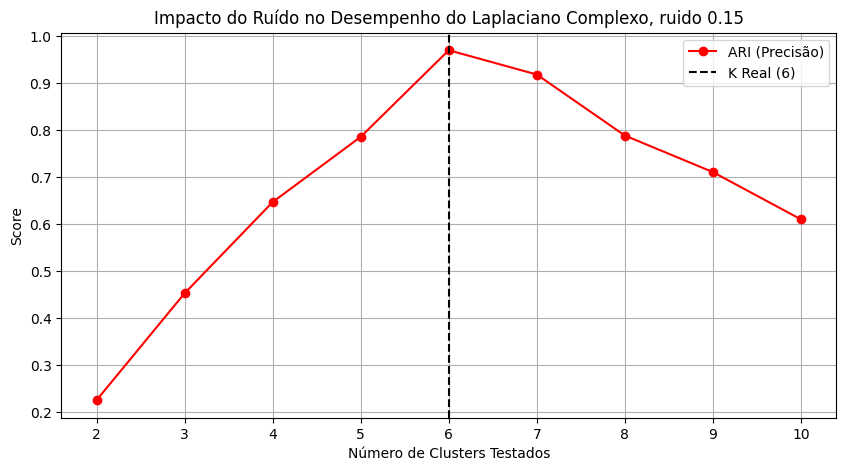

--- Gerando Grafo SBM Dirigido com 240 nós e 6 clusters ---

Testando de 2 a 10 clusters com ruído de 30.0%...
K=2 | ARI: 0.157
K=3 | ARI: 0.385
K=4 | ARI: 0.516
K=5 | ARI: 0.713
K=6 | ARI: 0.776
K=7 | ARI: 0.695
K=8 | ARI: 0.586
K=9 | ARI: 0.512
K=10 | ARI: 0.458


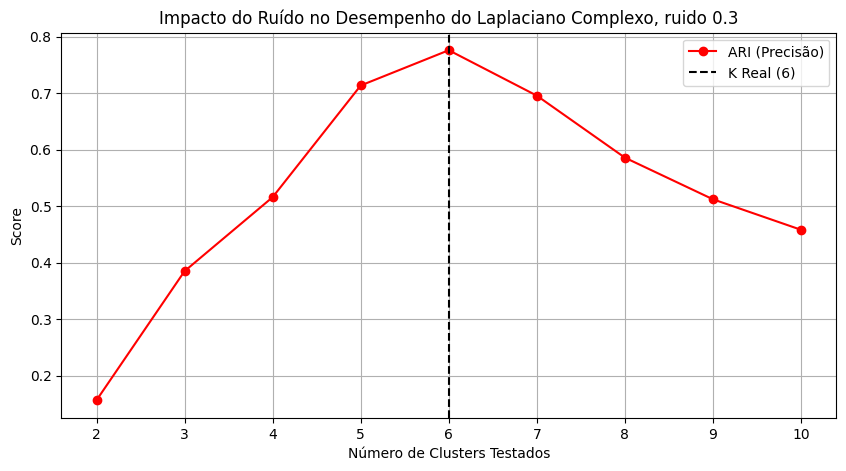

--- Gerando Grafo SBM Dirigido com 120 nós e 3 clusters ---

Testando de 2 a 10 clusters com ruído de 45.0%...
K=2 | ARI: 0.525
K=3 | ARI: 0.975
K=4 | ARI: 0.388
K=5 | ARI: 0.359
K=6 | ARI: 0.309
K=7 | ARI: 0.207
K=8 | ARI: 0.203
K=9 | ARI: 0.134
K=10 | ARI: 0.114


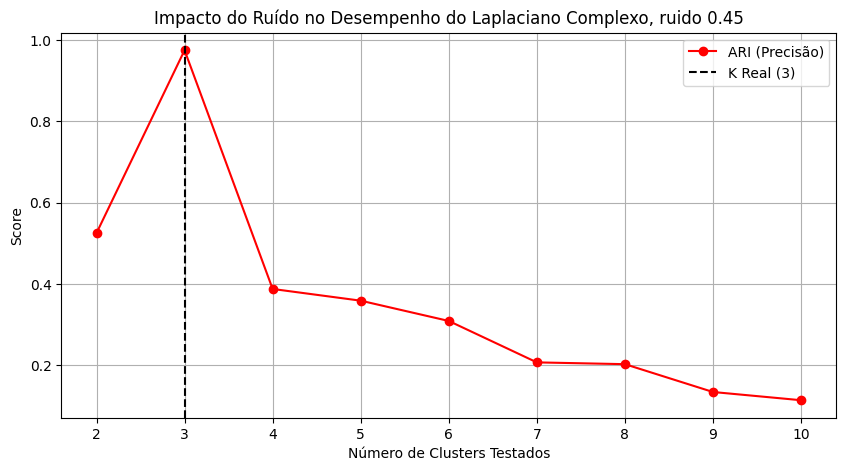

In [ ]:
def adicionar_ruido_aleatorio(G, prob_ruido=0.01):
    """
    Adiciona arestas aleatórias ao grafo para testar a robustez.
    """
    n_nos = G.number_of_nodes()
    for u in range(n_nos):
        for v in range(n_nos):
            if u != v and np.random.random() < prob_ruido:
                G.add_edge(u, v)
    return G
from sklearn.metrics import silhouette_score
import numpy as np
import networkx as nx
from sklearn.cluster import KMeans # Import KMeans
from scipy.linalg import eig # Import eig
from sklearn.metrics import adjusted_rand_score # Import adjusted_rand_score

def spectral_clustering_lc(G, n_clusters, alpha=0.90):
    """
    Executa o clustering usando o espectro do Laplaciano Complexo.
    Retorna: labels_pred, beta_sorted (autovalores), features (vetores complexos)
    """
    nodes = list(G.nodes())
    n = len(nodes)

    # 1. Matriz de Transição Ergódica (PageRank)
    # O alpha garante que o grafo seja fortemente conexo (irredutível)
    P = nx.google_matrix(G, alpha=alpha)
    P = np.array(P)

    # 2. Distribuição Estacionária (pi)
    vals, vecs = eig(P, left=True, right=False)
    idx_1 = np.argmin(np.abs(vals - 1.0))
    pi = np.real(vecs[:, idx_1])
    pi = pi / np.sum(pi)

    # 3. Construção do Laplaciano Complexo Lc
    # R_ij = sqrt(pi_i / pi_j)
    sqrt_pi = np.sqrt(pi)
    R = sqrt_pi[:, None] / sqrt_pi[None, :]
    Lc = -P * R
    np.fill_diagonal(Lc, 1 - np.diag(P))

    # 4. Decomposição Espectral
    beta, v = eig(Lc)

    # 5. Ordenação pelos autovalores (parte real)
    # A parte real indica a "energia" da partição
    idx = np.argsort(np.real(beta))
    beta_sorted = np.real(beta)[idx]
    v_sorted = v[:, idx]

    # 6. Seleção de Features (k vetores)
    # Concatenamos Real e Imaginário para capturar fluxos e ciclos
    k_vectors = v_sorted[:, 0:n_clusters]
    features = np.concatenate([np.real(k_vectors), np.imag(k_vectors)], axis=1)

    # 7. K-Means no espaço complexo mapeado
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels_pred = kmeans.fit_predict(features)

    return labels_pred, beta_sorted, features
def gerar_dados_sbm(n_clusters, n_por_bloco=40, p_intra=0.6, p_inter=0.02):
    """
    Gera um digrafo com n_clusters comunidades.
    """
    sizes = [n_por_bloco] * n_clusters  # Agora depende do parâmetro
    n_total = sum(sizes)

    # Criar matriz de probabilidades dinâmica (n_clusters x n_clusters)
    # Identidade * p_intra + (1 - Identidade) * p_inter
    probs = np.full((n_clusters, n_clusters), p_inter)
    np.fill_diagonal(probs, p_intra)

    print(f"--- Gerando Grafo SBM Dirigido com {n_total} nós e {n_clusters} clusters ---")
    G = nx.stochastic_block_model(sizes, probs, directed=True)

    labels_reais = np.array([G.nodes[i]['block'] for i in range(n_total)])
    return G, labels_reais, n_total
def testar_estabilidade_e_ruido(max_k=10, p_ruido=0.02):
    k_range = range(2, max_k + 1)
    aris = []
    silhouettes = []

    # 1. Gerar Grafo com 5 comunidades reais para o teste
    k_real = np.random.randint(2, max_k)
    G, labels_reais, n_total = gerar_dados_sbm(n_clusters=k_real, p_intra=0.5, p_inter=0.02)

    # 2. Injetar Ruído Extra
    G = adicionar_ruido_aleatorio(G, prob_ruido=p_ruido)

    print(f"\nTestando de 2 a {max_k} clusters com ruído de {p_ruido*100}%...")

    for k in k_range:
        # Executar clustering e desempacotar todos os retornos de uma vez
        labels_pred, autovalores, features = spectral_clustering_lc(G, n_clusters=k)

        # Calcular ARI (comparando com a verdade)
        ari = adjusted_rand_score(labels_reais, labels_pred)
        aris.append(ari)

        # Calcular Silhouette (estabilidade interna, não precisa dos labels reais)
        # O Silhouette agora mede a separação REAL no espaço complexo
        s_score = silhouette_score(features, labels_pred)
        silhouettes.append(s_score)

        print(f"K={k} | ARI: {ari:.3f}")

    return k_range, aris, k_real

# Execução
for i in range(0,10,3):
  ruido=i/20
  k_range, aris, k_real = testar_estabilidade_e_ruido(max_k=10, p_ruido=ruido)

# Visualização
  plt.figure(figsize=(10, 5))
  plt.plot(k_range, aris, 'ro-', label='ARI (Precisão)')
  plt.axvline(x=k_real, color='k', linestyle='--', label=f'K Real ({k_real})')
  plt.title(f"Impacto do Ruído no Desempenho do Laplaciano Complexo, ruido {ruido}")
  plt.xlabel("Número de Clusters Testados")
  plt.ylabel("Score")
  plt.legend()
  plt.grid(True)
  plt.show()

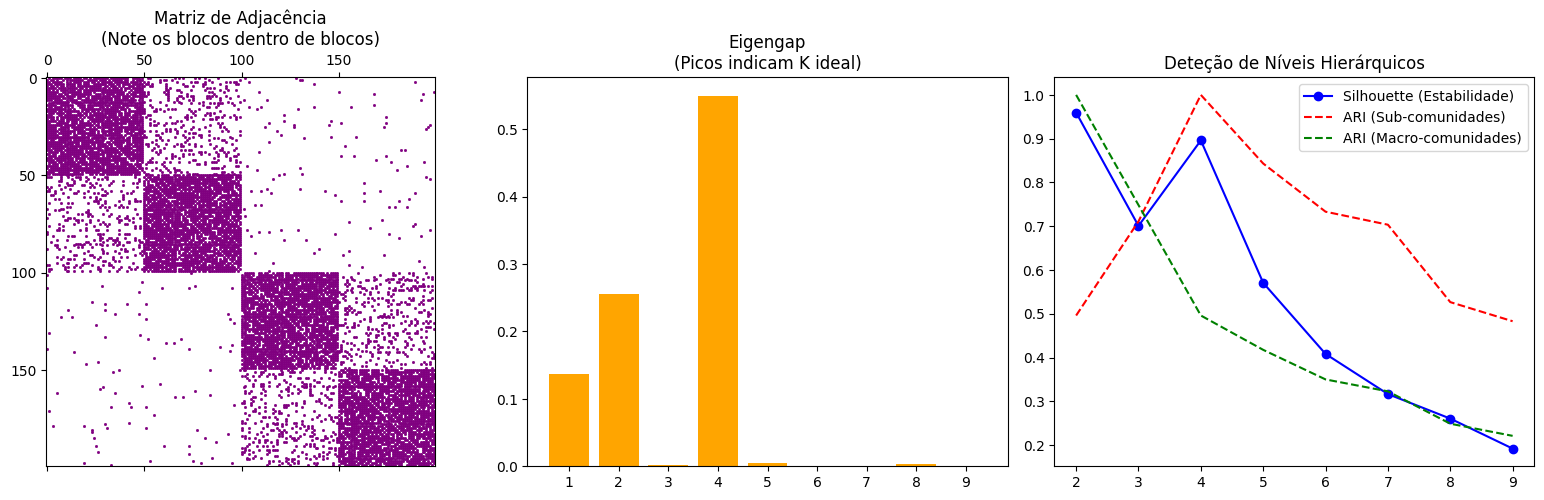

In [ ]:
def gerar_sbm_hierarquico():
    # 4 sub-blocos de 50 nós cada
    sizes = [50, 50, 50, 50]

    # Matriz de Probabilidades Hierárquica
    # B1 e B2 são "irmãos" (Grupo A) | B3 e B4 são "irmãos" (Grupo B)
    p_sub = 0.8   # Dentro do mini-bloco
    p_group = 0.15 # Entre blocos do mesmo grupo
    p_inter = 0.01 # Entre grupos rivais

    probs = [
        [p_sub,   p_group, p_inter, p_inter], # B1
        [p_group, p_sub,   p_inter, p_inter], # B2
        [p_inter, p_inter, p_sub,   p_group], # B3
        [p_inter, p_inter, p_group, p_sub]    # B4
    ]

    G = nx.stochastic_block_model(sizes, probs, directed=True)
    labels_reais = np.array([G.nodes[i]['block'] for i in range(200)])

    # Criar labels para o nível "Macro" (apenas 2 grupos)
    labels_macro = np.array([0 if i < 100 else 1 for i in range(200)])

    return G, labels_reais, labels_macro

G_h, labels_sub, labels_macro = gerar_sbm_hierarquico()

ks = range(2, 10)
silhouettes = []
ar_sub = []
ar_macro = []

# Pegamos os autovalores apenas uma vez (com k máximo)
aa ,  autovalores, nfn = spectral_clustering_lc(G_h, n_clusters=max(ks))

for k in ks:
    labels_pred, aaa, features = spectral_clustering_lc(G_h, n_clusters=k)

    # Medindo qualidade sem saber a resposta (Silhouette)
    silhouettes.append(silhouette_score(features, labels_pred))

    # Medindo contra a verdade (Sub e Macro)
    ar_sub.append(adjusted_rand_score(labels_sub, labels_pred))
    ar_macro.append(adjusted_rand_score(labels_macro, labels_pred))

# --- Visualização ---
plt.figure(figsize=(16, 5))

# Plot 1: Matriz de Adjacência (Visualizar a hierarquia)
plt.subplot(1, 3, 1)
plt.spy(nx.to_numpy_array(G_h), markersize=1, color='purple')
plt.title("Matriz de Adjacência\n(Note os blocos dentro de blocos)")

# Plot 2: Eigengap (Os saltos nos autovalores)
plt.subplot(1, 3, 2)
gaps = np.diff(autovalores[:10])
plt.bar(range(1, len(gaps)+1), gaps, color='orange')
plt.title("Eigengap\n(Picos indicam K ideal)")
plt.xticks(range(1, 10))

# Plot 3: Silhouette vs ARI
plt.subplot(1, 3, 3)
plt.plot(ks, silhouettes, 'b-o', label='Silhouette (Estabilidade)')
plt.plot(ks, ar_sub, 'r--', label='ARI (Sub-comunidades)')
plt.plot(ks, ar_macro, 'g--', label='ARI (Macro-comunidades)')
plt.legend()
plt.title("Deteção de Níveis Hierárquicos")

plt.tight_layout()
plt.show()